# Decision Trees: ID3 Algorithm with Entropy and Information Gain

## Table of Contents
1. [Introduction to Decision Trees](#intro)
2. [Entropy: Measuring Uncertainty](#entropy)
3. [Information Gain](#information-gain)
4. [The ID3 Algorithm](#id3-algorithm)
5. [Recursive Splitting Process](#recursive-splitting)
6. [Building Trees from Scratch](#building-trees)
7. [Handling Continuous Features](#continuous-features)
8. [Overfitting and Pruning](#overfitting)
9. [Practical Implementation](#implementation)
10. [Advantages and Limitations](#pros-cons)

---

## 1. Introduction to Decision Trees <a id='intro'></a>

### What is a Decision Tree?

A **decision tree** is a flowchart-like structure where:
- **Internal nodes** represent tests on features
- **Branches** represent outcomes of tests
- **Leaf nodes** represent class labels or predictions

### Tree Structure

```
                    Root Node
                  (Feature Test)
                   /         \
                  /           \
          Internal Node    Internal Node
          (Feature Test)   (Feature Test)
             /    \            /    \
            /      \          /      \
        Leaf      Leaf      Leaf    Leaf
       (Class)   (Class)   (Class) (Class)
```

### Decision Tree Learning

The process of building a decision tree from training data involves:
1. **Selecting the best feature** to split on at each node
2. **Recursively splitting** the data based on feature values
3. **Stopping** when a termination condition is met

### Key Questions

1. **How do we choose which feature to split on?**
   - Answer: Use information gain (ID3) or Gini impurity (CART)

2. **When do we stop splitting?**
   - All samples belong to same class
   - Maximum depth reached
   - Minimum samples per node reached
   - No more features to split on

3. **How do we handle overfitting?**
   - Pre-pruning: Stop growing tree early
   - Post-pruning: Grow full tree then prune back

### ID3 Algorithm Overview

**ID3** (Iterative Dichotomiser 3) was one of the first decision tree algorithms, developed by Ross Quinlan in 1986.

**Key characteristics:**
- Uses entropy and information gain for splitting
- Originally designed for categorical features
- Greedy algorithm (makes locally optimal choices)
- No backtracking
- Builds trees top-down

**Algorithm steps:**
1. Calculate entropy of target variable
2. For each feature, calculate information gain
3. Select feature with highest information gain
4. Split dataset based on selected feature
5. Recursively repeat for each subset
6. Stop when termination condition met

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris, make_classification
from collections import Counter
import warnings

# Set styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully
NumPy version: 2.0.2
Pandas version: 2.2.2


## 2. Entropy: Measuring Uncertainty <a id='entropy'></a>

### Definition

**Entropy** is a measure of impurity, disorder, or uncertainty in a dataset. It comes from information theory.

For a dataset with $K$ classes, entropy is defined as:

$$H(S) = -\sum_{i=1}^{K} p_i \log_2(p_i)$$

where:
- $S$ is the dataset
- $p_i$ is the proportion of samples belonging to class $i$
- $\log_2$ is the logarithm base 2 (measured in bits)
- By convention, $0 \log_2(0) = 0$

### Intuition

Entropy measures **how many bits are needed** to encode the class information:
- **Low entropy**: Data is pure (mostly one class)
- **High entropy**: Data is mixed (many classes represented equally)

### Properties

**Minimum entropy = 0**:
- Occurs when all samples belong to one class
- Perfect purity, no uncertainty
- Example: All samples are "Yes"

**Maximum entropy = $\log_2(K)$**:
- Occurs when samples are equally distributed across all $K$ classes
- Maximum uncertainty
- For binary classification: $H_{\max} = \log_2(2) = 1$ bit

**Binary classification entropy:**
$$H(S) = -p \log_2(p) - (1-p)\log_2(1-p)$$

where $p$ is the proportion of positive samples.

### Examples

**Example 1: Pure dataset**
- Dataset: [Yes, Yes, Yes, Yes]
- $p_{Yes} = 1.0$, $p_{No} = 0.0$
- $H = -1.0 \log_2(1.0) - 0.0 \log_2(0.0) = 0$ bits

**Example 2: Balanced dataset**
- Dataset: [Yes, Yes, No, No]
- $p_{Yes} = 0.5$, $p_{No} = 0.5$
- $H = -0.5 \log_2(0.5) - 0.5 \log_2(0.5) = 1$ bit

**Example 3: Skewed dataset**
- Dataset: [Yes, Yes, Yes, No]
- $p_{Yes} = 0.75$, $p_{No} = 0.25$
- $H = -0.75 \log_2(0.75) - 0.25 \log_2(0.25) \approx 0.811$ bits

In [2]:
# Implement entropy calculation

def calculate_entropy(y):
    """
    Calculate entropy of a label array
    
    Parameters:
    -----------
    y : array-like
        Array of class labels
    
    Returns:
    --------
    entropy : float
        Entropy value in bits
    """
    # Count occurrences of each class
    class_counts = np.bincount(y)
    # Calculate probabilities
    probabilities = class_counts / len(y)
    # Remove zero probabilities (for log calculation)
    probabilities = probabilities[probabilities > 0]
    # Calculate entropy
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

# Test with examples
print("Entropy Examples:")
print("="*70)

# Pure dataset
y_pure = np.array([1, 1, 1, 1])
entropy_pure = calculate_entropy(y_pure)
print(f"\n1. Pure dataset [1,1,1,1]:")
print(f"   Entropy = {entropy_pure:.6f} bits")

# Balanced dataset
y_balanced = np.array([1, 1, 0, 0])
entropy_balanced = calculate_entropy(y_balanced)
print(f"\n2. Balanced dataset [1,1,0,0]:")
print(f"   Entropy = {entropy_balanced:.6f} bits")

# Skewed dataset
y_skewed = np.array([1, 1, 1, 0])
entropy_skewed = calculate_entropy(y_skewed)
print(f"\n3. Skewed dataset [1,1,1,0]:")
print(f"   Entropy = {entropy_skewed:.6f} bits")

# Very skewed dataset
y_very_skewed = np.array([1, 1, 1, 1, 1, 1, 1, 0])
entropy_very_skewed = calculate_entropy(y_very_skewed)
print(f"\n4. Very skewed dataset [1,1,1,1,1,1,1,0]:")
print(f"   Entropy = {entropy_very_skewed:.6f} bits")

Entropy Examples:

1. Pure dataset [1,1,1,1]:
   Entropy = -0.000000 bits

2. Balanced dataset [1,1,0,0]:
   Entropy = 1.000000 bits

3. Skewed dataset [1,1,1,0]:
   Entropy = 0.811278 bits

4. Very skewed dataset [1,1,1,1,1,1,1,0]:
   Entropy = 0.543564 bits


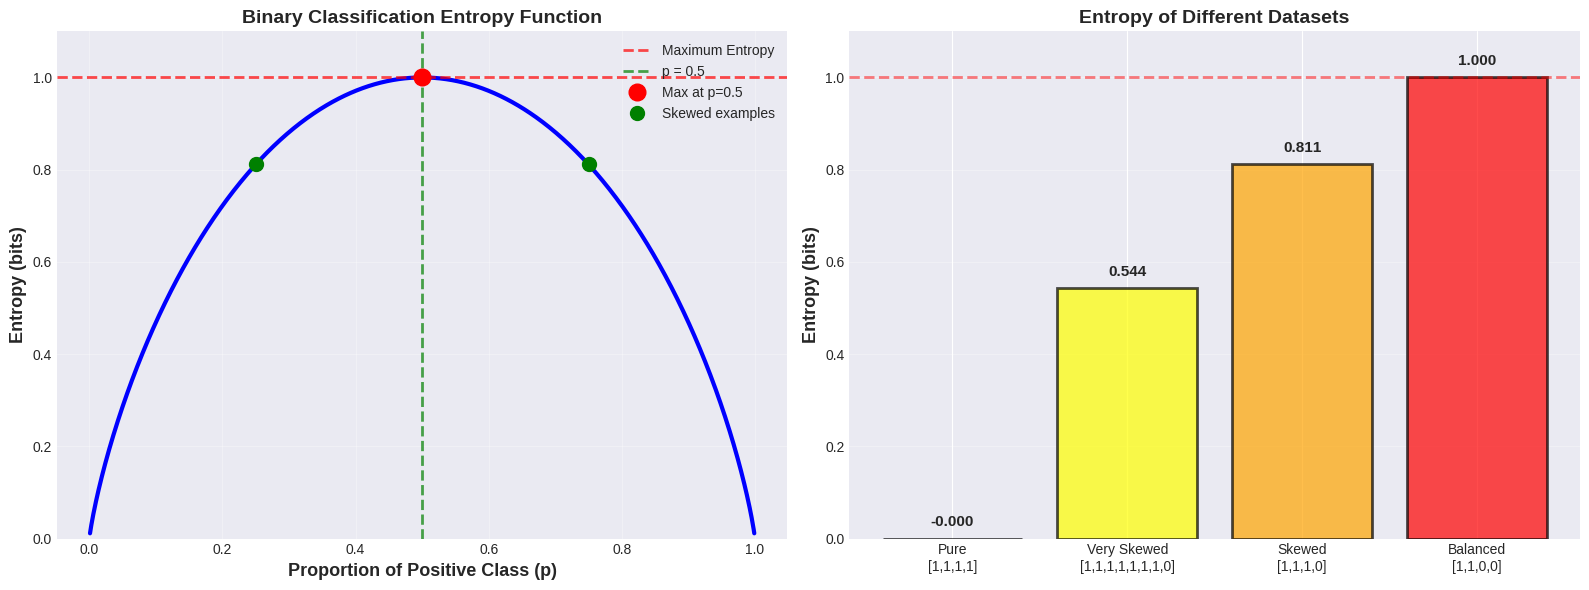


Key Observations:
  - Entropy is symmetric around p = 0.5
  - Maximum entropy (1 bit) occurs when classes are balanced
  - Minimum entropy (0 bits) occurs when dataset is pure
  - Entropy increases with class mixture


In [3]:
# Visualize entropy function for binary classification

# Create range of probabilities
p_range = np.linspace(0.001, 0.999, 1000)

# Calculate entropy for each probability
entropy_values = -p_range * np.log2(p_range) - (1 - p_range) * np.log2(1 - p_range)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Entropy curve
ax = axes[0]
ax.plot(p_range, entropy_values, 'b-', linewidth=3)
ax.axhline(y=1.0, color='r', linestyle='--', linewidth=2, alpha=0.7, label='Maximum Entropy')
ax.axvline(x=0.5, color='g', linestyle='--', linewidth=2, alpha=0.7, label='p = 0.5')

# Mark special points
ax.plot([0.5], [1.0], 'ro', markersize=12, label='Max at p=0.5')
ax.plot([0.25, 0.75], [calculate_entropy(np.array([1,1,1,0]))]*2, 
        'go', markersize=10, label='Skewed examples')

ax.set_xlabel('Proportion of Positive Class (p)', fontsize=13, fontweight='bold')
ax.set_ylabel('Entropy (bits)', fontsize=13, fontweight='bold')
ax.set_title('Binary Classification Entropy Function', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.1])

# Plot 2: Bar chart of example entropies
ax = axes[1]
examples = ['Pure\n[1,1,1,1]', 'Very Skewed\n[1,1,1,1,1,1,1,0]', 
            'Skewed\n[1,1,1,0]', 'Balanced\n[1,1,0,0]']
entropies = [entropy_pure, entropy_very_skewed, entropy_skewed, entropy_balanced]
colors = ['green', 'yellow', 'orange', 'red']

bars = ax.bar(examples, entropies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Entropy (bits)', fontsize=13, fontweight='bold')
ax.set_title('Entropy of Different Datasets', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.axhline(y=1.0, color='r', linestyle='--', linewidth=2, alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, entropy in zip(bars, entropies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{entropy:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - Entropy is symmetric around p = 0.5")
print("  - Maximum entropy (1 bit) occurs when classes are balanced")
print("  - Minimum entropy (0 bits) occurs when dataset is pure")
print("  - Entropy increases with class mixture")

## 3. Information Gain <a id='information-gain'></a>

### Definition

**Information Gain** measures the reduction in entropy after splitting on a feature. It tells us how much information a feature gives us about the class.

$$IG(S, A) = H(S) - H(S|A)$$

where:
- $IG(S, A)$ is the information gain of splitting dataset $S$ on attribute $A$
- $H(S)$ is the entropy before split
- $H(S|A)$ is the weighted average entropy after split

### Conditional Entropy

The conditional entropy $H(S|A)$ is calculated as:

$$H(S|A) = \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

where:
- $\text{Values}(A)$ are the possible values of attribute $A$
- $S_v$ is the subset of $S$ where attribute $A$ has value $v$
- $|S_v|$ is the size of subset $S_v$
- $|S|$ is the total size of dataset

### Intuition

Information gain answers:
**"How much does knowing this feature reduce our uncertainty about the class?"**

**High information gain**: Feature provides lots of information
- Subsets after split are purer
- Good feature for splitting

**Low information gain**: Feature provides little information
- Subsets after split remain mixed
- Poor feature for splitting

### Example Calculation

Consider this dataset:

| Outlook  | Temperature | Humidity | Wind   | Play |
|----------|-------------|----------|--------|------|
| Sunny    | Hot         | High     | Weak   | No   |
| Sunny    | Hot         | High     | Strong | No   |
| Overcast | Hot         | High     | Weak   | Yes  |
| Rain     | Mild        | High     | Weak   | Yes  |
| Rain     | Cool        | Normal   | Weak   | Yes  |
| Rain     | Cool        | Normal   | Strong | No   |
| Overcast | Cool        | Normal   | Strong | Yes  |
| Sunny    | Mild        | High     | Weak   | No   |

**Step 1**: Calculate entropy of Play
- Total samples: 8
- Yes: 4, No: 4
- $H(Play) = -0.5 \log_2(0.5) - 0.5 \log_2(0.5) = 1.0$ bit

**Step 2**: Calculate information gain for each feature

For **Outlook**:
- Sunny: [No, No, No] → Entropy = 0
- Overcast: [Yes, Yes] → Entropy = 0
- Rain: [Yes, Yes, No] → Entropy ≈ 0.918
- $H(Play|Outlook) = \frac{3}{8}(0) + \frac{2}{8}(0) + \frac{3}{8}(0.918) ≈ 0.344$
- $IG(Play, Outlook) = 1.0 - 0.344 = 0.656$ bits

This process is repeated for all features, and we select the one with highest information gain.

In [4]:
# Implement information gain calculation

def calculate_information_gain(X_column, y):
    """
    Calculate information gain for a single feature
    
    Parameters:
    -----------
    X_column : array-like
        Values of a single feature
    y : array-like
        Target labels
    
    Returns:
    --------
    information_gain : float
        Information gain value
    """
    # Calculate entropy before split
    total_entropy = calculate_entropy(y)
    
    # Get unique values and their counts
    values, counts = np.unique(X_column, return_counts=True)
    
    # Calculate weighted entropy after split
    weighted_entropy = 0
    for value, count in zip(values, counts):
        # Get subset where feature equals this value
        subset_indices = X_column == value
        subset_y = y[subset_indices]
        
        # Weight by proportion of samples
        weight = count / len(y)
        
        # Add weighted entropy of this subset
        subset_entropy = calculate_entropy(subset_y)
        weighted_entropy += weight * subset_entropy
    
    # Information gain is reduction in entropy
    information_gain = total_entropy - weighted_entropy
    
    return information_gain

# Create example dataset (Play Tennis)
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny',
                'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild',
                   'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High',
                'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak',
            'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No',
            'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

# Convert labels to numeric
label_mapping = {'No': 0, 'Yes': 1}
y = df['Play'].map(label_mapping).values

# Calculate entropy of target
target_entropy = calculate_entropy(y)

print("Play Tennis Dataset:")
print("="*70)
print(df)
print(f"\nTarget Distribution:")
print(df['Play'].value_counts())
print(f"\nEntropy of Play: {target_entropy:.4f} bits")

# Calculate information gain for each feature
print("\n" + "="*70)
print("Information Gain for Each Feature:")
print("="*70)

features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
information_gains = {}

for feature in features:
    # Convert to numeric codes
    X_column = pd.Categorical(df[feature]).codes
    ig = calculate_information_gain(X_column, y)
    information_gains[feature] = ig
    print(f"\n{feature}:")
    print(f"  Information Gain = {ig:.4f} bits")
    print(f"  Reduction in entropy: {(ig/target_entropy)*100:.2f}%")

best_feature = max(information_gains, key=information_gains.get)
print(f"\nBest feature to split on: {best_feature}")
print(f"Information Gain: {information_gains[best_feature]:.4f} bits")

Play Tennis Dataset:
     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No

Target Distribution:
Play
Yes    9
No     5
Name: count, dtype: int64

Entropy of Play: 0.9403 bits

Information Gain for Each Feature:

Outlook:
  Information Gain = 0.2467 bits
  Reduction in entropy: 26.24%

Temperature:
  Information Gain = 0.0292 bits
  Reduction in e

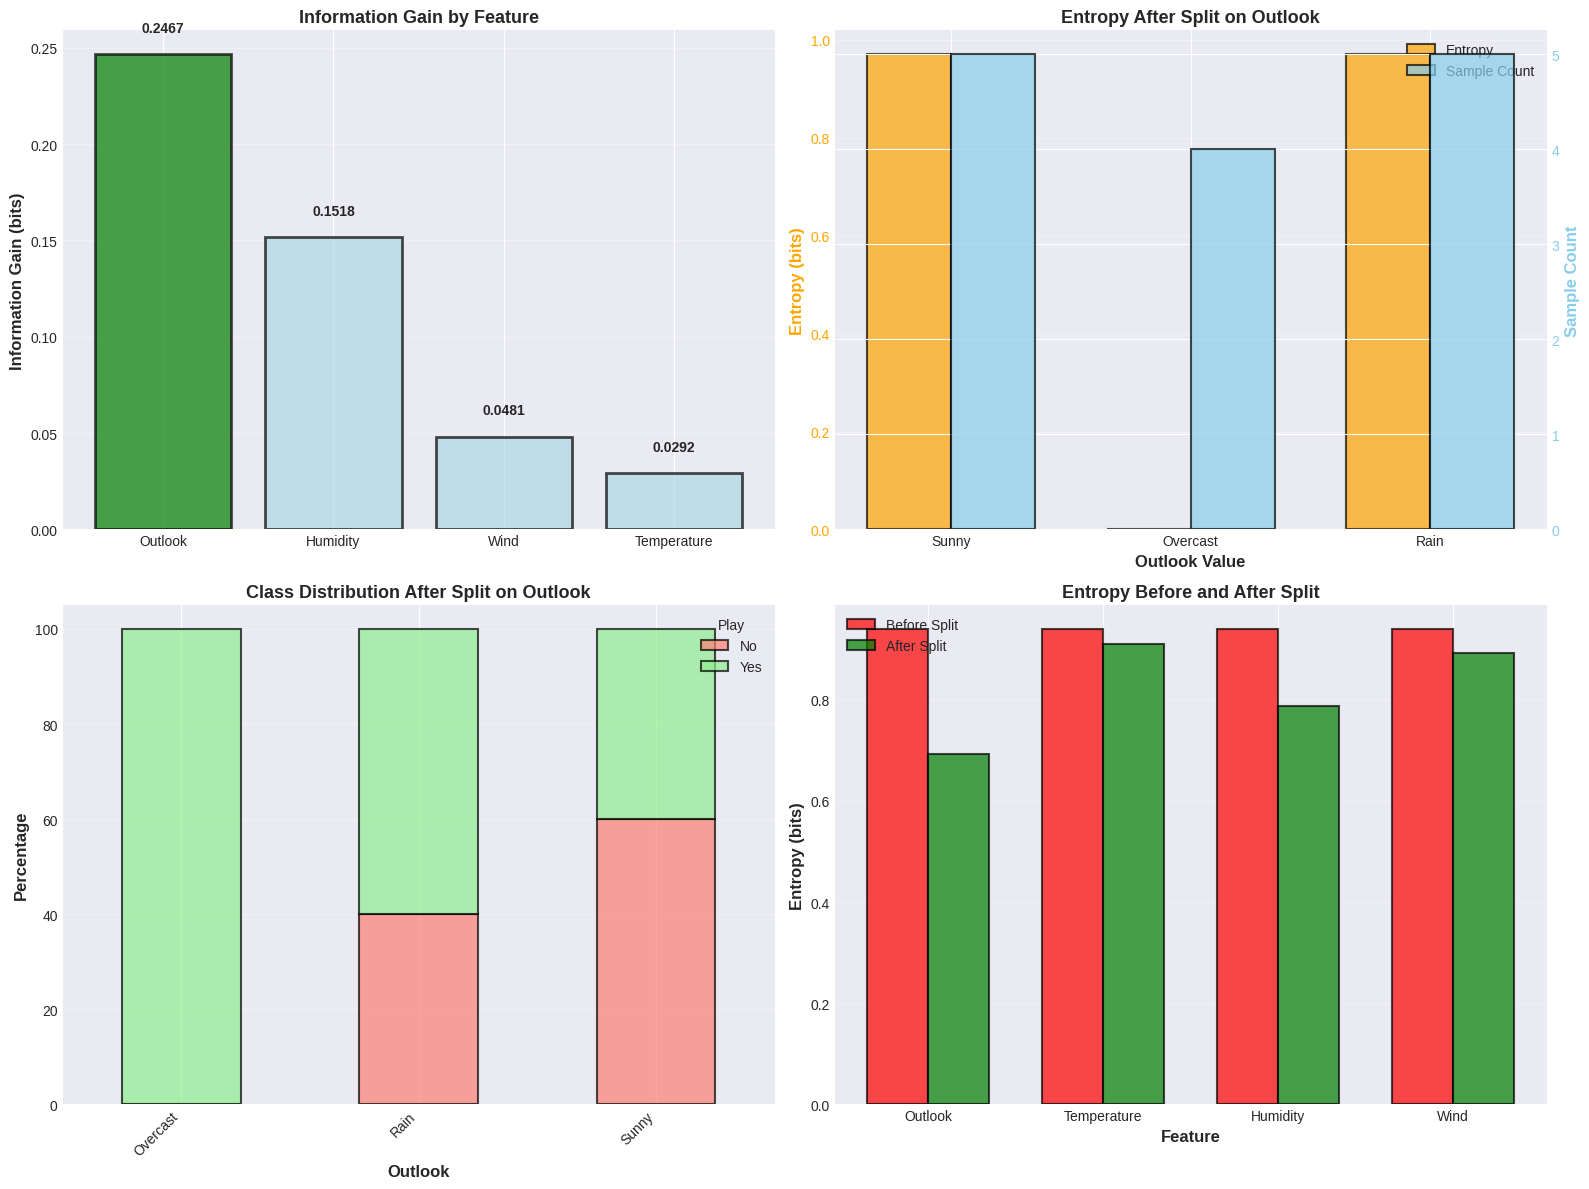


Visualization shows:
  1. Outlook has highest information gain
  2. Overcast subset is pure (entropy = 0)
  3. Splitting on Outlook significantly reduces entropy


In [5]:
# Visualize information gain

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Bar chart of information gains
ax = axes[0, 0]
features_sorted = sorted(information_gains.items(), key=lambda x: x[1], reverse=True)
feature_names = [f[0] for f in features_sorted]
ig_values = [f[1] for f in features_sorted]

colors = ['green' if i == 0 else 'lightblue' for i in range(len(feature_names))]
bars = ax.bar(feature_names, ig_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Information Gain (bits)', fontsize=12, fontweight='bold')
ax.set_title('Information Gain by Feature', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, ig in zip(bars, ig_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{ig:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Entropy breakdown for best feature (Outlook)
ax = axes[0, 1]
outlook_values = df['Outlook'].unique()
outlook_entropies = []
outlook_counts = []

for value in outlook_values:
    subset = df[df['Outlook'] == value]
    subset_y = subset['Play'].map(label_mapping).values
    outlook_entropies.append(calculate_entropy(subset_y))
    outlook_counts.append(len(subset))

x_pos = np.arange(len(outlook_values))
width = 0.35

ax2 = ax.twinx()
bars1 = ax.bar(x_pos - width/2, outlook_entropies, width, label='Entropy', 
              alpha=0.7, edgecolor='black', linewidth=1.5, color='orange')
bars2 = ax2.bar(x_pos + width/2, outlook_counts, width, label='Sample Count',
               alpha=0.7, edgecolor='black', linewidth=1.5, color='skyblue')

ax.set_xlabel('Outlook Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Entropy (bits)', fontsize=12, fontweight='bold', color='orange')
ax2.set_ylabel('Sample Count', fontsize=12, fontweight='bold', color='skyblue')
ax.set_title('Entropy After Split on Outlook', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(outlook_values)
ax.tick_params(axis='y', labelcolor='orange')
ax2.tick_params(axis='y', labelcolor='skyblue')
ax.grid(True, alpha=0.3, axis='y')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# Plot 3: Distribution of Play for each Outlook value
ax = axes[1, 0]
outlook_play_dist = pd.crosstab(df['Outlook'], df['Play'], normalize='index') * 100
outlook_play_dist.plot(kind='bar', stacked=True, ax=ax, color=['salmon', 'lightgreen'],
                       alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Outlook', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution After Split on Outlook', fontsize=13, fontweight='bold')
ax.legend(title='Play', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Comparison of entropy reduction
ax = axes[1, 1]
initial_entropy = [target_entropy] * len(features)
final_entropies = [target_entropy - information_gains[f] for f in features]

x = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x - width/2, initial_entropy, width, label='Before Split',
              alpha=0.7, edgecolor='black', linewidth=1.5, color='red')
bars2 = ax.bar(x + width/2, final_entropies, width, label='After Split',
              alpha=0.7, edgecolor='black', linewidth=1.5, color='green')

ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Entropy (bits)', fontsize=12, fontweight='bold')
ax.set_title('Entropy Before and After Split', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualization shows:")
print("  1. Outlook has highest information gain")
print("  2. Overcast subset is pure (entropy = 0)")
print("  3. Splitting on Outlook significantly reduces entropy")

## 4. The ID3 Algorithm <a id='id3-algorithm'></a>

### Algorithm Pseudocode

```
function ID3(data, target, features):
    # Base cases
    if all examples have same class:
        return leaf node with that class
    
    if features is empty:
        return leaf node with majority class
    
    # Recursive case
    best_feature = feature with highest information gain
    
    tree = create decision node for best_feature
    
    for each value v of best_feature:
        subset = examples where best_feature = v
        
        if subset is empty:
            add leaf with majority class
        else:
            remaining_features = features - {best_feature}
            subtree = ID3(subset, target, remaining_features)
            add subtree to tree under branch v
    
    return tree
```

### Step-by-Step Process

**Step 1: Check stopping conditions**
- All samples same class? → Return leaf
- No features left? → Return majority class
- Dataset empty? → Return parent majority class

**Step 2: Calculate information gain**
- For each remaining feature
- Select feature with highest IG

**Step 3: Create decision node**
- Split dataset on selected feature
- Create branch for each feature value

**Step 4: Recurse**
- For each branch
- Recursively build subtree
- Remove selected feature from available features

### Key Properties

**Greedy algorithm**: Makes locally optimal choice at each step
- Does not guarantee globally optimal tree
- But works well in practice

**Top-down construction**: Builds tree from root to leaves
- Also called "recursive partitioning"

**No backtracking**: Once a decision is made, it's not revisited
- Efficient but may miss better solutions

**Computational complexity**: $O(n \times m \times \log(m))$
- $n$ = number of features
- $m$ = number of samples

In [6]:
# Implement ID3 algorithm from scratch

class Node:
    """Node in decision tree"""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Feature index to split on
        self.threshold = threshold  # Threshold value (for continuous features)
        self.left = left           # Left subtree
        self.right = right         # Right subtree  
        self.value = value         # Class label (for leaf nodes)
    
    def is_leaf(self):
        return self.value is not None

class DecisionTreeID3:
    """
    Decision Tree using ID3 algorithm
    """
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.feature_names = None
    
    def fit(self, X, y, feature_names=None):
        """Build decision tree"""
        self.feature_names = feature_names
        self.root = self._build_tree(X, y, depth=0)
    
    def _build_tree(self, X, y, depth):
        """Recursively build decision tree"""
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Stopping criteria
        if (depth >= self.max_depth if self.max_depth else False) or \
           n_classes == 1 or \
           n_samples < self.min_samples_split:
            # Return leaf node with majority class
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Find best split
        best_feature, best_threshold = self._best_split(X, y)
        
        if best_feature is None:
            # No good split found
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Create child splits
        left_indices = X[:, best_feature] <= best_threshold
        right_indices = ~left_indices
        
        # Recursively build subtrees
        left_subtree = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self._build_tree(X[right_indices], y[right_indices], depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold,
                   left=left_subtree, right=right_subtree)
    
    def _best_split(self, X, y):
        """Find the best feature and threshold to split on"""
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        for feature_idx in range(X.shape[1]):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _information_gain(self, y, X_column, threshold):
        """Calculate information gain for a split"""
        # Parent entropy
        parent_entropy = self._entropy(y)
        
        # Create splits
        left_indices = X_column <= threshold
        right_indices = ~left_indices
        
        if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
            return 0
        
        # Calculate weighted average of child entropies
        n = len(y)
        n_left, n_right = len(y[left_indices]), len(y[right_indices])
        entropy_left, entropy_right = self._entropy(y[left_indices]), self._entropy(y[right_indices])
        child_entropy = (n_left / n) * entropy_left + (n_right / n) * entropy_right
        
        # Information gain
        return parent_entropy - child_entropy
    
    def _entropy(self, y):
        """Calculate entropy"""
        proportions = np.bincount(y) / len(y)
        proportions = proportions[proportions > 0]
        entropy = -np.sum(proportions * np.log2(proportions))
        return entropy
    
    def _most_common_label(self, y):
        """Return most common class label"""
        counter = Counter(y)
        return counter.most_common(1)[0][0]
    
    def predict(self, X):
        """Predict class labels for samples"""
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        """Traverse tree to make prediction for single sample"""
        if node.is_leaf():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def print_tree(self, node=None, depth=0):
        """Print tree structure"""
        if node is None:
            node = self.root
        
        indent = "  " * depth
        
        if node.is_leaf():
            print(f"{indent}Predict: {node.value}")
        else:
            feature_name = self.feature_names[node.feature] if self.feature_names else f"X{node.feature}"
            print(f"{indent}{feature_name} <= {node.threshold:.4f}")
            print(f"{indent}├─ True:")
            self.print_tree(node.left, depth + 1)
            print(f"{indent}└─ False:")
            self.print_tree(node.right, depth + 1)

print("ID3 Decision Tree class implemented")

ID3 Decision Tree class implemented


In [7]:
# Test ID3 implementation on Iris dataset

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train our ID3 implementation
tree_id3 = DecisionTreeID3(max_depth=3)
tree_id3.fit(X_train, y_train, feature_names=iris.feature_names)

# Make predictions
y_pred = tree_id3.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("ID3 Decision Tree Results:")
print("="*70)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"\nAccuracy: {accuracy:.4f}")

print("\n" + "="*70)
print("Tree Structure:")
print("="*70)
tree_id3.print_tree()

print("\n" + "="*70)
print("Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

ID3 Decision Tree Results:
Training samples: 120
Test samples: 30
Number of features: 4
Number of classes: 3

Accuracy: 0.9667

Tree Structure:
petal length (cm) <= 1.9000
├─ True:
  Predict: 0
└─ False:
  petal length (cm) <= 4.7000
  ├─ True:
    petal width (cm) <= 1.6000
    ├─ True:
      Predict: 1
    └─ False:
      Predict: 2
  └─ False:
    petal width (cm) <= 1.7000
    ├─ True:
      Predict: 2
    └─ False:
      Predict: 2

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



## 5. Summary and Key Takeaways

### Core Concepts

**Entropy**: Measure of impurity or uncertainty
- Range: [0, $\log_2(K)$] where $K$ is number of classes
- 0 = pure, max = maximum mixture
- Formula: $H(S) = -\sum_{i=1}^{K} p_i \log_2(p_i)$

**Information Gain**: Reduction in entropy after split
- Measures how much information a feature provides
- Formula: $IG(S, A) = H(S) - H(S|A)$
- Higher is better

**ID3 Algorithm**: Greedy, top-down tree building
- Select feature with highest information gain
- Recursively split until stopping criterion
- No backtracking

### Advantages

- Easy to understand and interpret
- No feature scaling required
- Handles both numerical and categorical data
- Non-parametric (no assumptions about data distribution)
- Can capture non-linear relationships
- Implicit feature selection

### Limitations

- Prone to overfitting
- Greedy algorithm may not find globally optimal tree
- Sensitive to small variations in data
- Biased toward features with many levels
- Can create biased trees if classes are imbalanced

### Best Practices

1. Set appropriate max_depth to prevent overfitting
2. Use min_samples_split to avoid tiny leaves
3. Consider pruning after building full tree
4. Use cross-validation for hyperparameter tuning
5. For continuous features, consider binning or using CART
6. Handle missing values appropriately
7. Consider ensemble methods (Random Forest) for better performance

Decision trees form the foundation for many advanced algorithms including Random Forests, Gradient Boosting, and XGBoost.